# SuStaIn applicato a FDG-PET in SLA
## Notebook template con dati sintetici

**Autore**: Fedele  
**Versione**: 0.3  
**Riferimento**: Young et al. *Nature Communications* 2018; Aksman et al. *SoftwareX* 2021

---

### Come usare questo notebook

Questo notebook ha due scopi:

1. **Didattico / dimostrativo**: i dati usati sono *sintetici* (generati artificialmente), con una struttura realistica modellata sul dataset ALS reale del progetto. Ogni cella è commentata per spiegare cosa fa e perché. Puoi eseguirlo dall'inizio alla fine anche senza dati reali.

2. **Template per i dati reali**: quando la pipeline MATLAB (Steps 1–7) sarà completata, basterà sostituire la sezione **"CARICAMENTO DATI"** con il vero file CSV degli z-score ROI. Il resto del notebook non cambia.

### Struttura del notebook

```
0.  Setup e import
1.  Il dataset sintetico — struttura e variabili cliniche
2.  Esplorazione dei dati (z-score ROI)
3.  Configurazione di SuStaIn
4.  Fitting del modello (Analisi 2a — dataset completo)
5.  Convergenza MCMC
5b. Diagnostica MCMC — trace e istogramma likelihood (tutti i modelli C)
6.  Selezione del numero ottimale di sottotipi (CVIC)
6b. Caricamento sequenze ottimali (cella di raccordo)
7.  Interpretazione — Positional Variance Diagrams
8.  Staging e subtyping dei pazienti
9.  Analisi post-hoc: correlazioni cliniche
10. Analisi 2b — C9orf72 isolato
10b. Diagnostica MCMC C9orf72
11. Analisi 2d — Validazione biologica SOD1
12. [SEZIONE DA COMPLETARE] Sostituzione con dati reali
```

---

### Contesto biologico

La **SLA (Sclerosi Laterale Amiotrofica)** è una malattia neurodegenerativa che colpisce i neuroni motori. Le forme genetiche più frequenti includono:
- **C9orf72** (~70 soggetti nel dataset): forma più comune, fenotipo variabile da motorio puro ad ALS-FTD
- **SOD1** (~20 soggetti): unica forma senza patologia TDP-43, fenotipo prevalentemente motorio
- TARDBP, FUS, altre forme rare

La **FDG-PET** misura il metabolismo glucidico cerebrale. La patologia in SLA causa **ipometabolismo** nelle regioni coinvolte. Questo notebook modella l'ipometabolismo come z-score rispetto a controlli sani (ADNI), con segno invertito: z-score **positivi** = più patologico.

## Cella 0 — Setup e import

Importiamo le librerie necessarie e configuriamo le cartelle di output.

**Librerie usate:**
- `numpy`, `pandas`: manipolazione dati
- `matplotlib`, `seaborn`: grafici
- `scipy.stats`: test statistici nelle analisi post-hoc
- `sklearn.model_selection`: KFold per la cross-validation
- `pySuStaIn`: l'algoritmo SuStaIn vero e proprio

Se `pySuStaIn` non è installato:
```bash
pip install pySuStaIn
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import os
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr, mannwhitneyu, kruskal
from sklearn.model_selection import KFold
import sklearn.model_selection
import pySuStaIn

# Seed per riproducibilità dei dati sintetici
np.random.seed(42)

# Cartella di output per i file pickle di SuStaIn
OUTPUT_FOLDER = 'output_sustain_als'
DATASET_NAME  = 'ALS_FDG_synthetic'
Path(OUTPUT_FOLDER).mkdir(exist_ok=True)

# FIX v0.2: pySuStaIn non espone __version__ — usiamo una verifica di import
print('Import completati.')
print('pySuStaIn importato correttamente.')

Import completati.
pySuStaIn importato correttamente.


---
## Cella 1 — Il dataset sintetico

### Struttura del dataset reale

Il dataset ALS reale del progetto include:

| Gruppo | N (atteso) | Note |
|--------|-----------|------|
| C9orf72 | ~70 | Forma più comune; fenotipo variabile |
| SOD1 | ~20 | Solo validazione biologica (non entra in SuStaIn) |
| TARDBP | ~15 | Solo analisi descrittiva |
| FUS | ~10 | Solo analisi descrittiva |
| Sporadica | ~85 | Forma senza mutazione genetica identificata |
| **Totale** | **~200** | |

**Variabili cliniche disponibili**: ALSFRS-R baseline, sede di insorgenza (bulbare/spinale), durata di malattia, ECAS (cognitivo), NfL plasmatico, ptau217, ptau181 (subset).

### Le 19 ROI (atlante AAL)

L'input a SuStaIn è una matrice di z-score medi per ROI, estratta dallo Step 7 della pipeline MATLAB. Le ROI coprono i domini rilevanti per ALS:

| Dominio | ROI | Razionale |
|---------|-----|-----------|
| Motorio | PreCentrale_sin, PreCentrale_dx, SMA | Core ALS |
| Prefrontale | FrontMedio_sin, FrontMedio_dx, OFC | C9orf72, ALS-FTD |
| Cingolato | Cing_ant, Cing_post | Marcatore cognitivo |
| Temporale | Temp_sup_sin, Temp_sup_dx, Temp_medio | ALS-FTD |
| Parietale | Pariet_sup_sin, Pariet_sup_dx | Cluster CPT |
| Subcorticale | Talamo_sin, Talamo_dx | Stadio avanzato |
| Cerebellare | Cerv_sup, Cerv_inf | C9orf72, forme rare |
| Controllo negativo | Occipitale, Insula | Attesi non coinvolti in ALS |

### Come sono strutturati i dati sintetici

Generiamo 3 sottotipi con sequenze di progressione diverse, ispirate alla letteratura ALS:
- **Sottotipo 1 (Motorio puro)**: ipometabolismo inizia nelle aree motorie, si estende lentamente
- **Sottotipo 2 (Fronto-motorio)**: ipometabolismo coinvolge precocemente anche il frontale e cingolato
- **Sottotipo 3 (Diffuso/CPT-like)**: pattern diffuso con coinvolgimento cerebellare precoce

I soggetti SOD1 sintetici vengono generati *separatamente* con il pattern del Sottotipo 1 (motorio puro), per replicare il loro ruolo di controllo positivo biologico.

In [2]:
# ==============================================================
# DEFINIZIONE DELLE ROI
# Queste etichette corrispondono alle ROI dell'atlante AAL
# che verranno estratte dallo Step 7 della pipeline MATLAB
# ==============================================================

ROI_LABELS = [
    # Motorio (core ALS)
    'PreCentrale_sin', 'PreCentrale_dx', 'SMA',
    # Prefrontale
    'FrontMedio_sin', 'FrontMedio_dx', 'OFC',
    # Cingolato
    'Cing_ant', 'Cing_post',
    # Temporale
    'Temp_sup_sin', 'Temp_sup_dx', 'Temp_medio',
    # Parietale
    'Pariet_sup_sin', 'Pariet_sup_dx',
    # Subcorticale
    'Talamo_sin', 'Talamo_dx',
    # Cerebellare
    'Cerv_sup', 'Cerv_inf',
    # Controllo negativo (attesi non coinvolti in ALS puro)
    'Occipitale',
    'Insula'
]

N_ROI = len(ROI_LABELS)

# Indici per dominio (utili per i grafici)
IDX_MOTORIO   = [0, 1, 2]
IDX_PREFRONT  = [3, 4, 5]
IDX_CINGOLATO = [6, 7]
IDX_TEMPORALE = [8, 9, 10]
IDX_PARIETALE = [11, 12]
IDX_SUBCORTIC = [13, 14]
IDX_CEREBB    = [15, 16]
IDX_ALTRO     = [17, 18]

print(f'ROI totali: {N_ROI}')
print('\nLista ROI:')
for i, r in enumerate(ROI_LABELS):
    print(f'  [{i:2d}] {r}')

ROI totali: 19

Lista ROI:
  [ 0] PreCentrale_sin
  [ 1] PreCentrale_dx
  [ 2] SMA
  [ 3] FrontMedio_sin
  [ 4] FrontMedio_dx
  [ 5] OFC
  [ 6] Cing_ant
  [ 7] Cing_post
  [ 8] Temp_sup_sin
  [ 9] Temp_sup_dx
  [10] Temp_medio
  [11] Pariet_sup_sin
  [12] Pariet_sup_dx
  [13] Talamo_sin
  [14] Talamo_dx
  [15] Cerv_sup
  [16] Cerv_inf
  [17] Occipitale
  [18] Insula


In [3]:
# ==============================================================
# GENERAZIONE DEL DATASET SINTETICO
# ==============================================================

def generate_als_synthetic_data(
        n_subtype1=70,
        n_subtype2=80,
        n_subtype3=30,
        n_sod1=20,
        noise_sd=0.8,
        seed=42
):
    """
    Genera un dataset sintetico di z-score ROI per pazienti ALS.
    Sottotipi:
      1 = Motorio puro
      2 = Fronto-motorio (coinvolgimento precoce frontale/cingolato)
      3 = Diffuso/CPT-like (cerebellare precoce)
    """
    np.random.seed(seed)

    seq_1 = [0, 1, 2, 13, 14, 3, 4, 6, 8, 9, 11, 12, 7, 15, 16, 5, 10, 17, 18]
    seq_2 = [0, 1, 6, 7, 3, 4, 5, 2, 8, 9, 10, 11, 12, 13, 14, 18, 15, 16, 17]
    seq_3 = [15, 16, 0, 1, 2, 11, 12, 6, 7, 3, 4, 13, 14, 8, 9, 10, 18, 5, 17]

    sequences = [seq_1, seq_2, seq_3]
    n_per_subtype = [n_subtype1, n_subtype2, n_subtype3]

    all_zscores, all_subtypes, all_stages = [], [], []

    for subtype_idx, (seq, n_sub) in enumerate(zip(sequences, n_per_subtype)):
        n_stages_total = N_ROI * 3
        for i in range(n_sub):
            true_stage = int(np.random.beta(2, 2) * n_stages_total)
            true_stage = np.clip(true_stage, 0, n_stages_total)
            z_roi = np.zeros(N_ROI)
            events_done = 0
            for roi_idx in seq:
                for z_level in [1, 2, 3]:
                    if events_done < true_stage:
                        z_roi[roi_idx] = max(z_roi[roi_idx], z_level)
                        events_done += 1
                    else:
                        break
            z_roi_noisy = z_roi + np.random.normal(0, noise_sd, N_ROI)
            z_roi_noisy = np.clip(z_roi_noisy, -1.5, 6.0)
            all_zscores.append(z_roi_noisy)
            all_subtypes.append(subtype_idx + 1)
            all_stages.append(true_stage)

    sod1_zscores = []
    for i in range(n_sod1):
        true_stage = int(np.random.beta(2, 2) * N_ROI * 3)
        z_roi = np.zeros(N_ROI)
        events_done = 0
        for roi_idx in seq_1:
            for z_level in [1, 2, 3]:
                if events_done < true_stage:
                    z_roi[roi_idx] = max(z_roi[roi_idx], z_level)
                    events_done += 1
        z_roi_noisy = z_roi + np.random.normal(0, noise_sd * 0.8, N_ROI)
        z_roi_noisy = np.clip(z_roi_noisy, -1.5, 6.0)
        sod1_zscores.append(z_roi_noisy)

    return (np.array(all_zscores), np.array(all_subtypes), np.array(all_stages),
            np.array(sod1_zscores), sequences)


zdata, true_subtypes, true_stages, zdata_sod1, ground_truth_sequences = \
    generate_als_synthetic_data()

N_subjects = len(zdata)
print(f'Dataset sintetico generato:')
print(f'  Pazienti ALS (training SuStaIn): {N_subjects}')
print(f'    - Sottotipo 1 (Motorio puro):    {np.sum(true_subtypes==1)}')
print(f'    - Sottotipo 2 (Fronto-motorio):  {np.sum(true_subtypes==2)}')
print(f'    - Sottotipo 3 (Diffuso/CPT):     {np.sum(true_subtypes==3)}')
print(f'  SOD1 (validazione biologica):     {len(zdata_sod1)}')
print(f'  ROI per soggetto:                 {N_ROI}')
print(f'\nMatrice z-score: {zdata.shape}')

Dataset sintetico generato:
  Pazienti ALS (training SuStaIn): 180
    - Sottotipo 1 (Motorio puro):    70
    - Sottotipo 2 (Fronto-motorio):  80
    - Sottotipo 3 (Diffuso/CPT):     30
  SOD1 (validazione biologica):     20
  ROI per soggetto:                 19

Matrice z-score: (180, 19)


In [4]:
# ==============================================================
# GENERAZIONE DATI CLINICI SINTETICI
# ==============================================================

n_als = N_subjects

onset_probs = {1: [0.75, 0.25], 2: [0.50, 0.50], 3: [0.60, 0.40]}
onset_site = np.array([
    np.random.choice(['Spinale', 'Bulbare'], p=onset_probs[st])
    for st in true_subtypes
])

mutation_map = {
    1: ['C9orf72']*30 + ['Sporadica']*30 + ['TARDBP']*5 + ['FUS']*5,
    2: ['C9orf72']*40 + ['Sporadica']*25 + ['TARDBP']*10 + ['FUS']*5,
    3: ['C9orf72']*15 + ['Sporadica']*10 + ['TARDBP']*3 + ['FUS']*2
}
mutations = np.array([
    np.random.choice(mutation_map[st]) for st in true_subtypes
])

alsfrs = np.clip(
    45 - 0.4 * true_stages + np.random.normal(0, 4, n_als), 0, 48
).astype(int)

ecas_mean = {1: 115, 2: 95, 3: 105}
ecas = np.array([
    int(np.clip(np.random.normal(ecas_mean[st], 12), 40, 136))
    for st in true_subtypes
])

nfl = np.clip(20 + 3.5 * true_stages + np.random.normal(0, 30, n_als), 5, 500)

ptau217_mean = {1: 1.2, 2: 2.8, 3: 1.8}
ptau217 = np.array([
    np.clip(np.random.lognormal(np.log(ptau217_mean[st]), 0.5), 0.1, 15)
    for st in true_subtypes
])
ptau217_mask = np.random.rand(n_als) < 0.4
ptau217[~ptau217_mask] = np.nan

age = np.clip(np.random.normal(62, 10, n_als), 35, 85).astype(int)
sex = np.random.choice(['M', 'F'], n_als, p=[0.60, 0.40])

df_clinical = pd.DataFrame({
    'subject_id':   [f'ALS_{i:04d}' for i in range(n_als)],
    'age_at_pet':   age,
    'sex':          sex,
    'mutation':     mutations,
    'onset_site':   onset_site,
    'alsfrs_total': alsfrs,
    'ecas_total':   ecas,
    'nfl_plasma':   np.round(nfl, 1),
    'ptau217':      np.round(ptau217, 3),
    'true_subtype': true_subtypes,  # disponibile solo con dati sintetici!
    'true_stage':   true_stages,    # disponibile solo con dati sintetici!
})

print('Dati clinici sintetici generati.')
print(f'\nDistribuzione mutazioni:')
print(df_clinical['mutation'].value_counts().to_string())
print(f'\nDistribuzione insorgenza:')
print(df_clinical['onset_site'].value_counts().to_string())
print(f'\nRange ALSFRS-R: {alsfrs.min()}–{alsfrs.max()} (media {alsfrs.mean():.1f})')
print(f'ptau217 disponibile: {(~np.isnan(ptau217)).sum()} soggetti')
df_clinical.head()

Dati clinici sintetici generati.

Distribuzione mutazioni:
C9orf72      81
Sporadica    63
FUS          22
TARDBP       14

Distribuzione insorgenza:
Spinale    110
Bulbare     70

Range ALSFRS-R: 18–48 (media 32.7)
ptau217 disponibile: 76 soggetti


,subject_id,age_at_pet,sex,mutation,onset_site,alsfrs_total,ecas_total,nfl_plasma,ptau217,true_subtype,true_stage
0,ALS_0000,61,M,Sporadica,Spinale,33,113,109.9,NaN,1,35
1,ALS_0001,77,F,FUS,Spinale,41,107,46.9,NaN,1,10
2,ALS_0002,66,M,Sporadica,Spinale,40,101,85.5,0.851,1,14
3,ALS_0003,75,M,TARDBP,Spinale,41,112,55.9,0.670,1,10
4,ALS_0004,63,F,C9orf72,Bulbare,36,116,106.2,0.282,1,23


---
## Cella 2 — Esplorazione dei dati

Prima di applicare SuStaIn, visualizziamo i dati grezzi.

**Due verifiche fondamentali:**
1. La struttura dei sottotipi è visibile nei dati bruti? (solo possibile con dati sintetici — ground truth noto)
2. Ci sono ROI con meno di 10 pazienti che superano le soglie z = 1, 2, 3? Queste vanno escluse dalla configurazione SuStaIn.

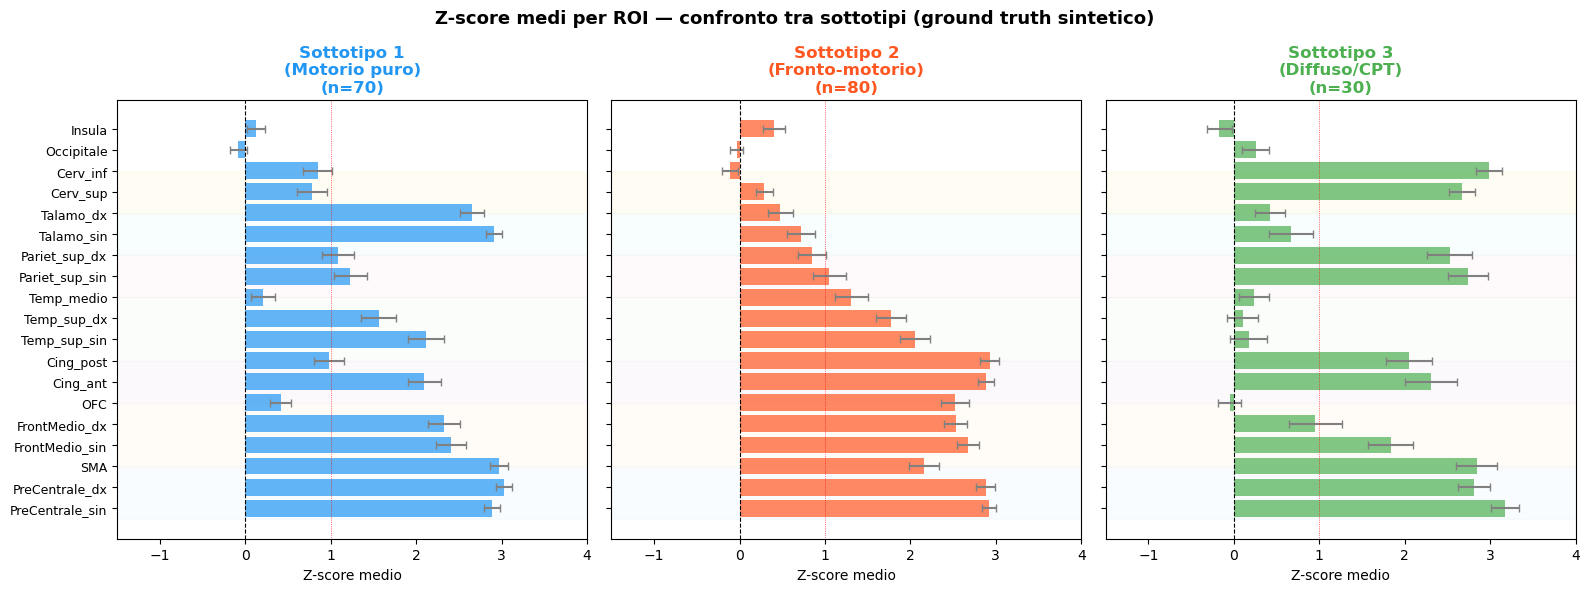

Nei dati REALI questa figura non è disponibile prima di SuStaIn.


In [5]:
# --- Z-score medi per ROI e per sottotipo (ground truth sintetico) ---

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
fig.suptitle('Z-score medi per ROI — confronto tra sottotipi (ground truth sintetico)',
             fontsize=13, fontweight='bold')

subtype_names = ['Sottotipo 1\n(Motorio puro)',
                 'Sottotipo 2\n(Fronto-motorio)',
                 'Sottotipo 3\n(Diffuso/CPT)']
colors = ['#2196F3', '#FF5722', '#4CAF50']

domain_bands = [
    (0, 2.5,  '#E3F2FD'), (2.5, 5.5, '#FFF3E0'), (5.5, 7.5, '#F3E5F5'),
    (7.5, 10.5,'#E8F5E9'), (10.5,12.5,'#FCE4EC'), (12.5,14.5,'#E0F7FA'),
    (14.5,16.5,'#FFF9C4'),
]

for k, (st, name, col) in enumerate(zip([1,2,3], subtype_names, colors)):
    mask = true_subtypes == st
    mean_z = zdata[mask].mean(axis=0)
    se_z   = zdata[mask].std(axis=0) / np.sqrt(mask.sum())
    axes[k].barh(range(N_ROI), mean_z, xerr=se_z, color=col, alpha=0.7,
                 ecolor='gray', capsize=3)
    axes[k].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    axes[k].axvline(x=1, color='red', linewidth=0.5, linestyle=':')
    axes[k].set_title(f'{name}\n(n={mask.sum()})', color=col, fontweight='bold')
    axes[k].set_xlabel('Z-score medio')
    axes[k].set_xlim(-1.5, 4)
    for y0, y1, bc in domain_bands:
        axes[k].axhspan(y0-0.5, y1-0.5, alpha=0.2, color=bc, zorder=0)

axes[0].set_yticks(range(N_ROI))
axes[0].set_yticklabels(ROI_LABELS, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/fig_zscores_per_subtype.png', dpi=150, bbox_inches='tight')
plt.show()
print('Nei dati REALI questa figura non è disponibile prima di SuStaIn.')

In [6]:
# --- Verifica soglie z-score (criterio: >= 10 pazienti per evento) ---

print('='*60)
print('VERIFICA SOGLIE Z-SCORE (criterio: >= 10 pazienti per evento)')
print('='*60)

threshold_check = pd.DataFrame(index=ROI_LABELS, columns=['z>1', 'z>2', 'z>3'])
for i, roi in enumerate(ROI_LABELS):
    for z_thr in [1, 2, 3]:
        n_above = np.sum(zdata[:, i] > z_thr)
        flag = '' if n_above >= 10 else '  ← ATTENZIONE (<10)'
        threshold_check.loc[roi, f'z>{z_thr}'] = f'{n_above}{flag}'

print(threshold_check.to_string())
print('\nNota: gli eventi con <10 pazienti vanno esclusi dalla configurazione SuStaIn.')

VERIFICA SOGLIE Z-SCORE (criterio: >= 10 pazienti per evento)
                 z>1                    z>2                    z>3
PreCentrale_sin  179                    163                     77
PreCentrale_dx   174                    157                     81
SMA              155                    137                     75
FrontMedio_sin   150                    125                     73
FrontMedio_dx    136                    111                     64
OFC               81                     60                     42
Cing_ant         148                    138                     80
Cing_post        126                    103                     60
Temp_sup_sin     110                     90                     55
Temp_sup_dx       91                     72                     44
Temp_medio        59                     35                     22
Pariet_sup_sin    95                     75                     42
Pariet_sup_dx     81                     65                     34


---
## Cella 3 — Configurazione di SuStaIn

### I parametri fondamentali

**`Z_vals`** — la matrice degli eventi z-score possibili per ogni biomarcatore. Forma: `(N_ROI, N_z_events)`. Con 3 eventi: `[[1,2,3], [1,2,3], ...]`.

**`Z_max`** — il valore massimo atteso per ogni ROI, usato per normalizzare la visualizzazione. Tipicamente il 95° percentile dei dati, con minimo 5.

**`N_S_max`** — numero massimo di sottotipi da cercare (Cmax). Dataset completo ALS: 5. C9orf72 isolato: 3.

**`N_iterations_MCMC`** — campioni MCMC. Demo: `1e4`. Analisi finale: `1e6` (ore sul GEEKOM).

**`N_startpoints`** — ripartenze per evitare ottimi locali. Standard: 25.

In [7]:
# ==============================================================
# CONFIGURAZIONE SUSTAIN — ANALISI 2a (DATASET COMPLETO)
# ==============================================================

Z_vals = np.array([[1, 2, 3]] * N_ROI, dtype=float)
Z_max  = np.array([max(5, np.percentile(zdata[:, i], 95))
                   for i in range(N_ROI)], dtype=float)

print('Z_max per ROI:')
for roi, zm in zip(ROI_LABELS, Z_max):
    print(f'  {roi:20s}: {zm:.2f}')

N_S_max           = 5
N_startpoints     = 25
# FIX: per dati reali usa int(1e6)
N_iterations_MCMC = int(1e4)

print(f'\nN_iterations_MCMC: {N_iterations_MCMC:,}')
print('⚠️  Per dati reali usa 1e6 (richiede ore — usa tmux sul GEEKOM)')

sustain_input = pySuStaIn.ZscoreSustain(
    data              = zdata,
    Z_vals            = Z_vals,
    Z_max             = Z_max,
    biomarker_labels  = ROI_LABELS,
    N_startpoints     = N_startpoints,
    N_S_max           = N_S_max,
    N_iterations_MCMC = N_iterations_MCMC,
    output_folder     = OUTPUT_FOLDER,
    dataset_name      = DATASET_NAME,
    use_parallel_startpoints = False
)

print(f'\nSuStaIn configurato:')
print(f'  N pazienti:   {N_subjects}')
print(f'  N ROI:        {N_ROI}')
print(f'  Stadi totali: {N_ROI * 3} (= {N_ROI} ROI × 3 z-score)')
print(f'  Cmax:         {N_S_max}')
print(f'  Output:       {OUTPUT_FOLDER}/')

Z_max per ROI:
  PreCentrale_sin     : 5.00
  PreCentrale_dx      : 5.00
  SMA                 : 5.00
  FrontMedio_sin      : 5.00
  FrontMedio_dx       : 5.00
  OFC                 : 5.00
  Cing_ant            : 5.00
  Cing_post           : 5.00
  Temp_sup_sin        : 5.00
  Temp_sup_dx         : 5.00
  Temp_medio          : 5.00
  Pariet_sup_sin      : 5.00
  Pariet_sup_dx       : 5.00
  Talamo_sin          : 5.00
  Talamo_dx           : 5.00
  Cerv_sup            : 5.00
  Cerv_inf            : 5.00
  Occipitale          : 5.00
  Insula              : 5.00

N_iterations_MCMC: 10,000
⚠️  Per dati reali usa 1e6 (richiede ore — usa tmux sul GEEKOM)

SuStaIn configurato:
  N pazienti:   180
  N ROI:        19
  Stadi totali: 57 (= 19 ROI × 3 z-score)
  Cmax:         5
  Output:       output_sustain_als/


---
## Cella 4 — Fitting del modello SuStaIn

`run_sustain_algorithm()` esegue il fitting per C = 1..Cmax. Per ogni C:
1. Cerca la sequenza ottimale con `N_startpoints` ripartenze
2. Esegue il campionamento MCMC
3. Salva il risultato in un file pickle

Se il calcolo viene interrotto, riprende dai pickle esistenti.

**Output principali:**
- `samples_sequence` `(N_S_max, N_eventi, N_iter)`: campioni MCMC delle sequenze
- `samples_f` `(N_S_max, N_iter)`: proporzioni dei sottotipi
- `ml_subtype`, `ml_stage`: assegnazioni più probabili per ogni paziente

In [8]:
print('Avvio SuStaIn...')
print('I risultati vengono salvati progressivamente in:', OUTPUT_FOLDER + '/pickle_files/')
print()

samples_sequence, samples_f, ml_subtype, prob_ml_subtype, \
    ml_stage, prob_ml_stage, prob_subtype_stage = \
    sustain_input.run_sustain_algorithm()

print('\nFitting completato!')
print(f'samples_sequence shape: {samples_sequence.shape}  → (N_S_max, N_eventi, N_iter)')
print(f'samples_f shape:        {samples_f.shape}  → (N_S_max, N_iter)')
print(f'ml_subtype shape:       {ml_subtype.shape}  → (N_pazienti, 1)')
print(f'ml_stage shape:         {ml_stage.shape}  → (N_pazienti, 1)')

Avvio SuStaIn...
I risultati vengono salvati progressivamente in: output_sustain_als/pickle_files/

Found pickle file: output_sustain_als/pickle_files/ALS_FDG_synthetic_subtype0.pickle. Using pickled variables for 0 subtype.
Found pickle file: output_sustain_als/pickle_files/ALS_FDG_synthetic_subtype1.pickle. Using pickled variables for 1 subtype.
Found pickle file: output_sustain_als/pickle_files/ALS_FDG_synthetic_subtype2.pickle. Using pickled variables for 2 subtype.
Found pickle file: output_sustain_als/pickle_files/ALS_FDG_synthetic_subtype3.pickle. Using pickled variables for 3 subtype.
Found pickle file: output_sustain_als/pickle_files/ALS_FDG_synthetic_subtype4.pickle. Using pickled variables for 4 subtype.

Fitting completato!
samples_sequence shape: (5, 57, 10000)  → (N_S_max, N_eventi, N_iter)
samples_f shape:        (5, 10000)  → (N_S_max, N_iter)
ml_subtype shape:       (180, 1)  → (N_pazienti, 1)
ml_stage shape:         (180, 1)  → (N_pazienti, 1)


---
## Cella 5 — Convergenza MCMC

Prima di interpretare i risultati, verifica che il MCMC abbia **convergito**.

Visualizziamo il trace della proporzione `f` di ogni sottotipo nel modello a C=3 (il numero vero nei dati sintetici). Un trace convergente mostra oscillazioni stabili attorno a un valore fisso nella seconda metà del campionamento.

- **Buona convergenza**: il valore si stabilizza dopo il burn-in (linea rossa = 20% delle iterazioni)
- **Non convergenza**: trend sistematici fino alla fine → aumentare `N_iterations_MCMC`

**Nota**: con 1e4 iterazioni (demo) il trace del sottotipo più piccolo (Sottotipo 3, n=30) può apparire piatto — comportamento atteso con poche iterazioni. Con 1e6 iterazioni sarà mobile.

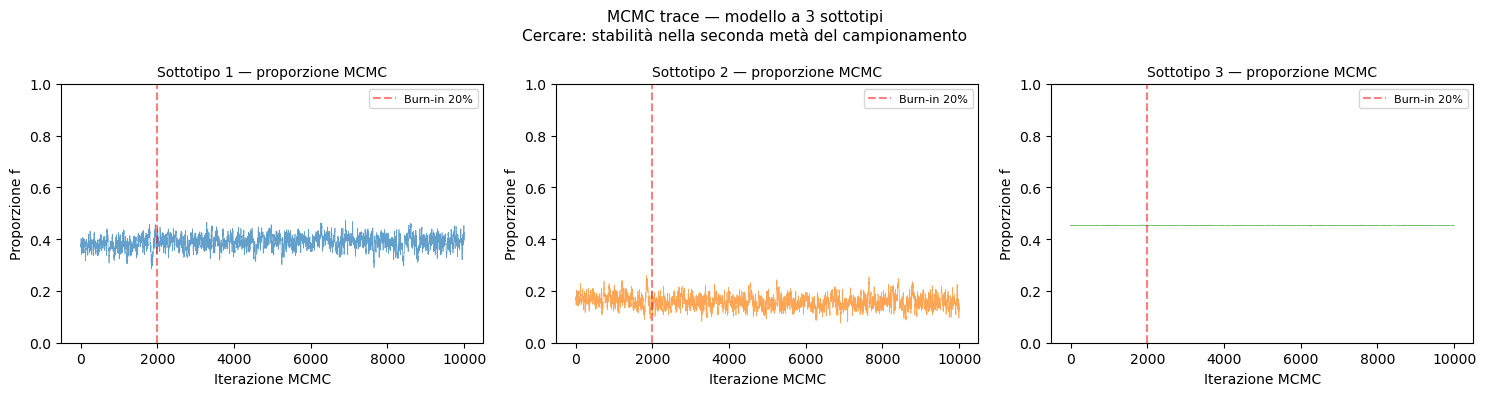

In [9]:
N_to_check = 3  # modello a 3 sottotipi (il numero vero nei dati sintetici)
s = N_to_check - 1

pickle_file = f'{OUTPUT_FOLDER}/pickle_files/{DATASET_NAME}_subtype{s}.pickle'

try:
    pk = pickle.load(open(pickle_file, 'rb'))
    samples_sequence_s = pk['samples_sequence']
    samples_f_s        = pk['samples_f']

    fig, axes = plt.subplots(1, N_to_check, figsize=(5*N_to_check, 4))
    if N_to_check == 1:
        axes = [axes]

    for k in range(N_to_check):
        # FIX v0.2: samples_f_s è 2D (N_sottotipi, N_iter), non 3D
        f_trace = samples_f_s[k, :]  # shape: (N_iter,)
        axes[k].plot(f_trace, alpha=0.7, linewidth=0.5, color=f'C{k}')
        axes[k].set_title(f'Sottotipo {k+1} — proporzione MCMC', fontsize=10)
        axes[k].set_xlabel('Iterazione MCMC')
        axes[k].set_ylabel('Proporzione f')
        axes[k].set_ylim(0, 1)
        burnin = int(0.2 * len(f_trace))
        axes[k].axvline(burnin, color='red', linestyle='--', alpha=0.5, label='Burn-in 20%')
        axes[k].legend(fontsize=8)

    fig.suptitle(f'MCMC trace — modello a {N_to_check} sottotipi\n'
                 'Cercare: stabilità nella seconda metà del campionamento',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_FOLDER}/fig_mcmc_trace.png', dpi=150)
    plt.show()

except FileNotFoundError:
    print(f'File pickle non trovato: {pickle_file}')
    print('Assicurati che il fitting (Cella 4) sia completato.')

---
## Cella 5b — Likelihood MCMC per tutti i modelli (C = 1…Cmax)

La Cella 5 mostra il trace della proporzione `f` per un singolo modello (C=3). Questa cella aggiunge due grafici diagnostici complementari che confrontano **tutti i modelli C = 1…Cmax** in un'unica figura:

| Figura | Cosa mostra | Cosa cercare |
|--------|-------------|---------------|
| **Trace log-likelihood** | Evoluzione della log-likelihood campionata dal MCMC per ogni C | Stabilizzazione rapida, assenza di trend sistematici a fine catena |
| **Istogramma log-likelihood** | Distribuzione dei campioni MCMC per ogni C | Distribuzione unimodale e simmetrica = buona convergenza; bimodalità = possibile trappola locale |

### Interpretazione nel contesto ALS-PET

- I modelli con **C più alto** tendono ad avere log-likelihood maggiore in assoluto — è atteso, non è un criterio di selezione
- La **forma** degli istogrammi è più informativa del valore assoluto: una distribuzione piatta o bimodale segnala che il modello non è stabile
- Confrontare visivamente la separazione tra le distribuzioni di C adiacenti: se C=2 e C=3 si sovrappongono molto, il modello più complesso non aggiunge informazione

> **Nei dati sintetici** con 1e4 iterazioni, gli istogrammi saranno più rumorosi del normale. Con 1e6 iterazioni sui dati reali le distribuzioni saranno molto più regolari.


In [ ]:
# --- Trace e istogramma della log-likelihood per C = 1...Cmax ---
# Ogni curva/barra corrisponde a un diverso numero di sottotipi.
# Fonte: samples_likelihood salvata nel pickle del modello completo (non dei fold CV).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 0.9, N_S_max))

for s in range(N_S_max):
    pkl_file = f'{OUTPUT_FOLDER}/pickle_files/{DATASET_NAME}_subtype{s}.pickle'
    pk = pickle.load(open(pkl_file, 'rb'))
    samples_ll = pk['samples_likelihood']
    col = colors[s]
    label = f'C={s+1}'

    # Trace
    axes[0].plot(range(len(samples_ll)), samples_ll,
                 color=col, alpha=0.8, linewidth=0.6, label=label)

    # Istogramma
    axes[1].hist(samples_ll, bins=40, color=col, alpha=0.5, label=label, density=True)

# Linea burn-in (20% delle iterazioni)
burnin = int(0.2 * N_iterations_MCMC)
axes[0].axvline(burnin, color='black', linestyle='--', linewidth=1.2,
                label=f'Burn-in (20% = {burnin:,} iter)')

axes[0].set_xlabel('Campioni MCMC', fontsize=12)
axes[0].set_ylabel('Log-likelihood', fontsize=12)
axes[0].set_title('Trace log-likelihood — tutti i modelli C', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(True, alpha=0.2)

axes[1].set_xlabel('Log-likelihood', fontsize=12)
axes[1].set_ylabel('Densità', fontsize=12)
axes[1].set_title('Distribuzione log-likelihood — tutti i modelli C', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.suptitle(f'Diagnostica MCMC — Analisi 2a (dataset completo, N={N_subjects})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/fig_mcmc_likelihood.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretazione rapida:')
print('  - Trace stabili dopo il burn-in → buona convergenza')
print('  - Istogrammi unimodali e simmetrici → modello stabile')
print('  - Istogrammi bimodali → possibile trappola locale (aumentare N_startpoints)')


---
## Cella 6 — Selezione del numero ottimale di sottotipi (CVIC)

### Perché non usare il numero di sottotipi con log-likelihood più alta?

Più sottotipi aggiungi, più il modello si adatta ai dati — ma rischi l'**overfitting**: il modello impara a memoria i pazienti del training invece di catturare struttura biologica reale.

### La cross-validation

I dati vengono divisi in K=10 gruppi (fold). Per ogni numero di sottotipi:
- Si addestra SuStaIn su 9 fold
- Si valuta la bontà di fit sull'1 fold escluso (come se fossero nuovi pazienti)
- Si ripete per tutti i 10 fold

Il **CVIC** (Cross-Validation Information Criterion) viene restituito direttamente da `cross_validate_sustain_model`. Come AIC e BIC, un **CVIC più basso** indica un modello migliore — bilancia complessità e accuratezza penalizzando i modelli troppo complessi. Il numero ottimale di sottotipi è quello con **CVIC minimo** (`np.argmin`).

> ⚠️ **Nota critica v0.3**: nelle versioni precedenti il CVIC veniva calcolato manualmente dai pickle dei fold e si usava `np.argmax` — entrambi errati. `cross_validate_sustain_model` restituisce `(CVIC, loglike_matrix)` e il criterio corretto è `np.argmin(CVIC)`.

### Interpretazione pratica

- Se il CVIC mostra un minimo netto → il numero ottimale è chiaro
- Se la differenza tra modelli adiacenti è < ~6 unità → si preferisce il modello più parsimonioso (meno sottotipi)
- La `loglike_matrix` (N_folds × N_S_max) permette di vedere la stabilità del fit per fold

### Note implementative

- La firma corretta è `cross_validate_sustain_model(test_idxs=...)` — richiede gli indici dei fold generati con `KFold`
- Il metodo salva automaticamente i pickle dei fold in `{output_folder}/pickle_files/`
- Se i pickle esistono già, la cross-validation non viene rieseguita (utile per riprendere dopo interruzioni)


In [10]:
# --- Cross-validation ---
# FIX v0.2: la firma corretta usa test_idxs, non n_folds o n_splits

print('Avvio cross-validation (10-fold)...')
print('Con i dati reali e 1e6 iter questo può richiedere un giorno intero.')
print()

kf = KFold(n_splits=10, shuffle=True, random_state=42)
test_idxs = [test_idx for _, test_idx in kf.split(zdata)]

cv_fold_assignments = sustain_input.cross_validate_sustain_model(test_idxs=test_idxs)

print('Cross-validation completata.')

Avvio cross-validation (10-fold)...
Con i dati reali e 1e6 iter questo può richiedere un giorno intero.



Folds:   0%|          | 0/10 [00:00<?, ?it/s]

Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold0_subtype0.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold0_subtype1.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold0_subtype2.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold0_subtype3.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold0_subtype4.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold1_subtype0.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold1_subtype1.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold1_subtype2.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold1_subtype3.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold1_subtype4.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold2_subtype0.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold2_subtype1.pickle
Loading output_sustain_als/pickle_files/

In [ ]:
# FIX v0.3: cross_validate_sustain_model restituisce (CVIC, loglike_matrix) direttamente.
# NON è necessario caricare i pickle dei fold manualmente.
# Il CVIC ottimale corrisponde al MINIMO (np.argmin), non al massimo.

CVIC, loglike_matrix = sustain_input.cross_validate_sustain_model(test_idxs=test_idxs)

n_subtypes_range = np.arange(1, N_S_max + 1)
optimal_n = int(n_subtypes_range[np.argmin(CVIC)])

print('CVIC per modello di sottotipi:')
for s, c in enumerate(CVIC):
    marker = ' ← ottimale' if (s + 1) == optimal_n else ''
    print(f'  C={s+1}: CVIC = {c:.4e}{marker}')

# Grafico CVIC
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pannello 1: CVIC
ax = axes[0]
ax.plot(n_subtypes_range, CVIC, 'o-', color='#1565C0', linewidth=2,
        markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.axvline(optimal_n, color='#E53935', linestyle='--', linewidth=1.5,
           label=f'N ottimale = {optimal_n}')
ax.scatter([optimal_n], [CVIC[optimal_n - 1]], color='#E53935', s=100, zorder=5)
ax.set_xlabel('Numero di sottotipi', fontsize=12)
ax.set_ylabel('CVIC', fontsize=12)
ax.set_title('Selezione numero ottimale di sottotipi\n(CVIC minimo = migliore)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Pannello 2: log-likelihood per fold (boxplot — stabilità del fit)
ax = axes[1]
df_loglike = pd.DataFrame(
    data=loglike_matrix,
    columns=[f'C={i+1}' for i in range(N_S_max)]
)
df_loglike.boxplot(ax=ax, grid=False)
ax.set_xlabel('Modello di sottotipi', fontsize=12)
ax.set_ylabel('Log-likelihood test set (per fold)', fontsize=12)
ax.set_title('Stabilità del fit per fold\n(varianza attesa nei dati sintetici)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/fig_cvic.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nNumero ottimale di sottotipi (CVIC): {optimal_n}')
print(f'Ground truth sintetico:              3')


---
## Cella 6b — Caricamento sequenze ottimali

Cella di raccordo: carica dal pickle le sequenze MCMC per il numero ottimale di sottotipi.
Tutte le celle successive (PVD, staging, analisi post-hoc) dipendono da `samples_sequence_opt` e `samples_f_opt`.

**Esegui sempre questa cella dopo la Cella 6**, anche se riapri il notebook dopo un'interruzione.

> **Nota v0.3**: il nome del pickle è `{DATASET_NAME}_subtype{s}.pickle` dove `s = optimal_n - 1` (indice 0-based). Questo è il file del modello completo addestrato su tutti i dati, distinto dai file `_fold{k}_subtype{s}.pickle` prodotti dalla cross-validation.


In [12]:
# FIX v0.2: cella di raccordo — evita NameError nelle celle successive
# se la Cella 6 viene saltata o rieseguita parzialmente

print(f'Numero ottimale di sottotipi selezionato: {optimal_n}')

s = optimal_n - 1
pkl_opt = pickle.load(open(
    f'{OUTPUT_FOLDER}/pickle_files/{DATASET_NAME}_subtype{s}.pickle', 'rb'
))
samples_sequence_opt = pkl_opt['samples_sequence']
samples_f_opt        = pkl_opt['samples_f']

print(f'Sequenze ottimali caricate dal pickle (subtype{s}).')
print(f'samples_sequence_opt shape: {samples_sequence_opt.shape}')
print(f'samples_f_opt shape:        {samples_f_opt.shape}')

Numero ottimale di sottotipi selezionato: 5
Sequenze ottimali caricate dal pickle (subtype4).
samples_sequence_opt shape: (5, 57, 10000)
samples_f_opt shape:        (5, 10000)


---
## Cella 7 — Positional Variance Diagrams (PVD)

I PVD sono la **visualizzazione principale** di SuStaIn. Ogni PVD descrive la progressione di un sottotipo.

### Come si legge un PVD

```
Righe    : ogni evento = (ROI, soglia z)
           Con 19 ROI × 3 soglie = 57 righe
Colonne  : stadi di progressione (1 → N_stadi)
Colore   : probabilità che quell'evento avvenga in quello stadio
           Rosso = z=1  |  Magenta = z=2  |  Blu = z=3
```

**PVD ben definito**: struttura diagonale netta — ogni evento ha alta probabilità in uno stadio specifico.

**PVD incerto**: colori dispersi su molti stadi → il sottotipo non è ben separato dai dati.

### Note implementative

`pySuStaIn.ZscoreSustain._plot_sustain_model` è il metodo interno usato anche nei tutorial ufficiali (es. `SuStaIn_tutorial_using_simulated_data.ipynb`). Nonostante l'underscore (convenzione Python per i metodi 'protetti'), è stabile nell'API corrente di pySuStaIn e il suo utilizzo diretto è documentato negli esempi ufficiali.

In alternativa, la funzione statica `ZscoreSustain.plot_positional_var(samples_sequence, samples_f, n_samples, Z_vals, ...)` produce lo stesso output con un'interfaccia leggermente diversa.

### Cosa cercare nel contesto ALS-PET
- **Sottotipo Motorio**: ROI motorie (PreCentrale sin/dx, SMA) nelle prime colonne
- **Sottotipo Fronto-motorio**: ROI frontali e cingolate nelle prime colonne insieme alle motorie
- **Sottotipo Diffuso/CPT**: ROI cerebellari (Cerv_sup, Cerv_inf) nelle primissime colonne


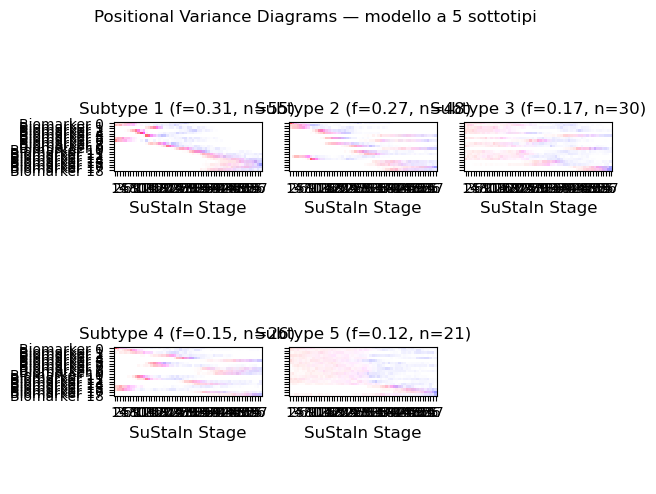

Sottotipi ordinati per proporzione decrescente: [4, 1, 5, 2, 3]


In [14]:
# --- Positional Variance Diagrams ---

try:
    M = len(zdata)
    # Ordina i sottotipi per proporzione decrescente (convenzione)
    f_mean = samples_f_opt.mean(axis=-1).flatten()[:optimal_n]
    subtype_order = tuple(np.argsort(-f_mean))

    fig = pySuStaIn.ZscoreSustain._plot_sustain_model(
        sustain_input,
        samples_sequence_opt,
        samples_f_opt,
        M,
        subtype_order=subtype_order
    )
    plt.suptitle(f'Positional Variance Diagrams — modello a {optimal_n} sottotipi',
                 fontsize=12, y=1.02)
    plt.savefig(f'{OUTPUT_FOLDER}/fig_pvd_optimal.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Sottotipi ordinati per proporzione decrescente: {[s+1 for s in subtype_order]}')

except Exception as e:
    print(f'Errore nel plot PVD: {e}')

---
## Cella 8 — Staging e subtyping dei pazienti

Una volta identificato il numero ottimale di sottotipi, SuStaIn assegna a ogni paziente:
- Il **sottotipo** più probabile
- Lo **stadio** più probabile
- La distribuzione completa delle probabilità

Lo stadio non è una misura temporale — è una misura di *quantità di patologia accumulata* secondo la sequenza del sottotipo assegnato.

In [29]:
# --- Staging e subtyping con il modello ottimale ---

# FIX v0.2: subtype_and_stage_individuals richiede l'oggetto dati interno
# accessibile tramite name mangling di Python
sustainData = sustain_input._ZscoreSustain__sustainData

ml_subtype_opt, prob_subtype_opt, ml_stage_opt, prob_stage_opt, \
    prob_subtype_opt2, prob_stage_opt2, prob_subtype_stage_opt = \
    sustain_input.subtype_and_stage_individuals(
        sustainData, samples_sequence_opt, samples_f_opt, N_samples=1000
    )

df_clinical['sustain_subtype'] = ml_subtype_opt.astype(int) + 1  # 1-indexed
df_clinical['sustain_stage']   = ml_stage_opt.astype(int)
df_clinical['sustain_prob']    = prob_subtype_opt

print('Distribuzione dei sottotipi identificati da SuStaIn:')
print(df_clinical['sustain_subtype'].value_counts().sort_index().to_string())
print()
print('Stadio medio ± SD per sottotipo:')
print(df_clinical.groupby('sustain_subtype')['sustain_stage'].agg(['mean','std']).round(1).to_string())

Distribuzione dei sottotipi identificati da SuStaIn:
1    62
2    48
3    23
4    27
5    20

Stadio medio ± SD per sottotipo:
                 mean  std
sustain_subtype           
1                20.9  8.7
2                16.7  8.5
3                33.7  4.5
4                20.7  8.1
5                37.5  4.1


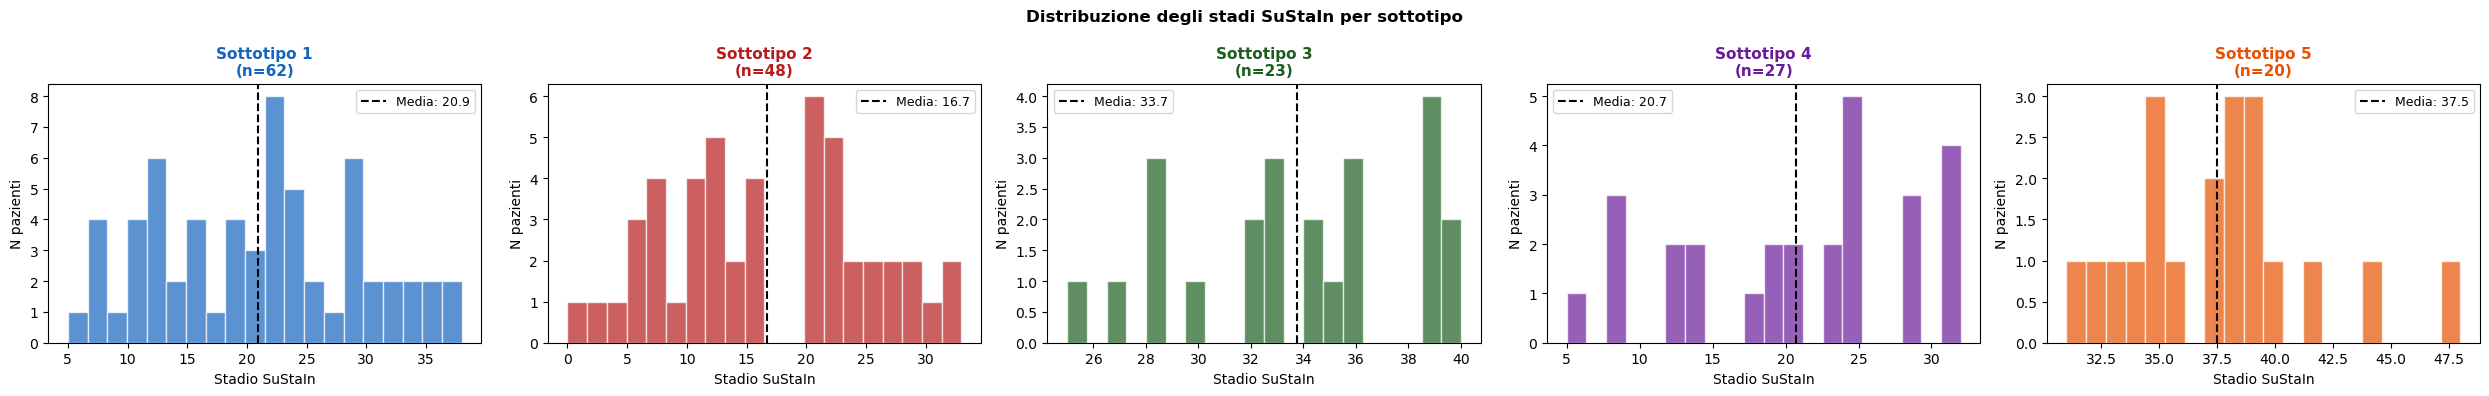

In [30]:
# --- Distribuzione degli stadi per sottotipo ---

fig, axes = plt.subplots(1, optimal_n, figsize=(5*optimal_n, 4), sharey=False)
if optimal_n == 1:
    axes = [axes]

colors_st = ['#1565C0', '#B71C1C', '#1B5E20', '#6A1B9A', '#E65100']

for k in range(optimal_n):
    mask = df_clinical['sustain_subtype'] == (k+1)
    stages_k = df_clinical.loc[mask, 'sustain_stage']
    axes[k].hist(stages_k, bins=20, color=colors_st[k], alpha=0.7, edgecolor='white')
    axes[k].set_title(f'Sottotipo {k+1}\n(n={mask.sum()})',
                      fontsize=11, fontweight='bold', color=colors_st[k])
    axes[k].set_xlabel('Stadio SuStaIn', fontsize=10)
    axes[k].set_ylabel('N pazienti', fontsize=10)
    axes[k].axvline(stages_k.mean(), color='black', linestyle='--',
                    linewidth=1.5, label=f'Media: {stages_k.mean():.1f}')
    axes[k].legend(fontsize=9)

fig.suptitle('Distribuzione degli stadi SuStaIn per sottotipo',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/fig_stage_distribution.png', dpi=150)
plt.show()

In [31]:
# --- Confronto SuStaIn vs. Ground truth (SOLO DATI SINTETICI) ---
# Commentare questa cella quando si usano i dati reali.

print('Tabella di contingenza: Sottotipo SuStaIn vs. Ground truth')
ct = pd.crosstab(
    df_clinical['sustain_subtype'],
    df_clinical['true_subtype'],
    rownames=['SuStaIn (stimato)'],
    colnames=['Ground truth (vero)']
)
print(ct.to_string())
print()
print('Una buona corrispondenza mostra valori alti su una diagonale (eventualmente permutata).')

r, p = spearmanr(df_clinical['true_stage'], df_clinical['sustain_stage'])
print(f'\nCorrelazione stadio vero vs. stimato: Spearman r={r:.3f}, p={p:.2e}')

Tabella di contingenza: Sottotipo SuStaIn vs. Ground truth
Ground truth (vero)   1   2   3
SuStaIn (stimato)              
1                     1  61   0
2                    46   2   0
3                    20   0   3
4                     0   0  27
5                     3  17   0

Una buona corrispondenza mostra valori alti su una diagonale (eventualmente permutata).

Correlazione stadio vero vs. stimato: Spearman r=0.973, p=9.43e-115


---
## Cella 9 — Analisi post-hoc: correlazioni cliniche

Dopo l'assegnazione di sottotipo e stadio, si esplorano le associazioni con le variabili cliniche.

**Importante**: queste sono analisi *esplorative* post-hoc. Non entrano nell'algoritmo. Per la pubblicazione sono necessarie correzioni per test multipli (Bonferroni o FDR).

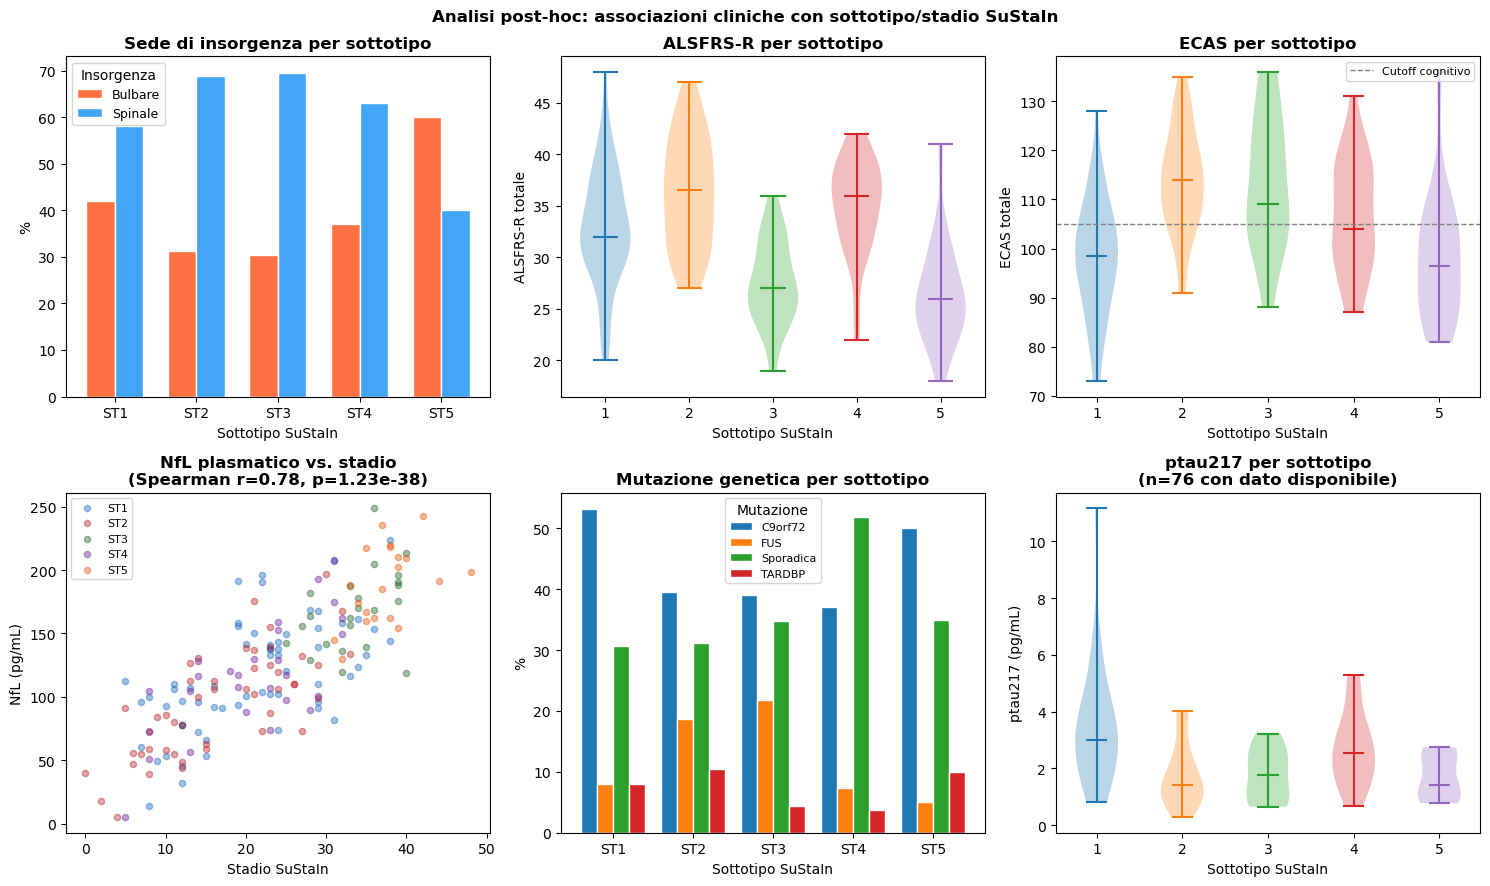

In [32]:
# --- Pannello di correlazioni cliniche ---

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Analisi post-hoc: associazioni cliniche con sottotipo/stadio SuStaIn',
             fontsize=12, fontweight='bold')

colors_sub = {k+1: colors_st[k] for k in range(optimal_n)}

# 1. Sede di insorgenza per sottotipo
ax = axes[0, 0]
onset_cross = pd.crosstab(df_clinical['sustain_subtype'],
                          df_clinical['onset_site'], normalize='index') * 100
onset_cross.plot(kind='bar', ax=ax, color=['#FF7043','#42A5F5'],
                 edgecolor='white', width=0.7)
ax.set_title('Sede di insorgenza per sottotipo', fontweight='bold')
ax.set_xlabel('Sottotipo SuStaIn')
ax.set_ylabel('%')
ax.set_xticklabels([f'ST{i}' for i in onset_cross.index], rotation=0)
ax.legend(title='Insorgenza', fontsize=9)

# 2. ALSFRS-R per sottotipo
ax = axes[0, 1]
for st in sorted(df_clinical['sustain_subtype'].unique()):
    ax.violinplot(df_clinical[df_clinical['sustain_subtype']==st]['alsfrs_total'],
                  positions=[st], showmedians=True, widths=0.6)
ax.set_title('ALSFRS-R per sottotipo', fontweight='bold')
ax.set_xlabel('Sottotipo SuStaIn')
ax.set_ylabel('ALSFRS-R totale')
ax.set_xticks(sorted(df_clinical['sustain_subtype'].unique()))

# 3. ECAS per sottotipo
ax = axes[0, 2]
for st in sorted(df_clinical['sustain_subtype'].unique()):
    ax.violinplot(df_clinical[df_clinical['sustain_subtype']==st]['ecas_total'],
                  positions=[st], showmedians=True)
ax.axhline(105, color='gray', linestyle='--', linewidth=1, label='Cutoff cognitivo')
ax.set_title('ECAS per sottotipo', fontweight='bold')
ax.set_xlabel('Sottotipo SuStaIn')
ax.set_ylabel('ECAS totale')
ax.set_xticks(sorted(df_clinical['sustain_subtype'].unique()))
ax.legend(fontsize=8)

# 4. NfL vs. stadio SuStaIn
ax = axes[1, 0]
for st in sorted(df_clinical['sustain_subtype'].unique()):
    mask = df_clinical['sustain_subtype'] == st
    ax.scatter(df_clinical.loc[mask, 'sustain_stage'],
               df_clinical.loc[mask, 'nfl_plasma'],
               alpha=0.4, s=20, color=colors_sub[st], label=f'ST{st}')
r_nfl, p_nfl = spearmanr(df_clinical['sustain_stage'], df_clinical['nfl_plasma'])
ax.set_title(f'NfL plasmatico vs. stadio\n(Spearman r={r_nfl:.2f}, p={p_nfl:.2e})',
             fontweight='bold')
ax.set_xlabel('Stadio SuStaIn')
ax.set_ylabel('NfL (pg/mL)')
ax.legend(fontsize=8)

# 5. Distribuzione mutazioni per sottotipo
ax = axes[1, 1]
mut_cross = pd.crosstab(df_clinical['sustain_subtype'],
                        df_clinical['mutation'], normalize='index') * 100
mut_cross.plot(kind='bar', ax=ax, edgecolor='white', width=0.8)
ax.set_title('Mutazione genetica per sottotipo', fontweight='bold')
ax.set_xlabel('Sottotipo SuStaIn')
ax.set_ylabel('%')
ax.set_xticklabels([f'ST{i}' for i in mut_cross.index], rotation=0)
ax.legend(title='Mutazione', fontsize=8)

# 6. ptau217 per sottotipo
ax = axes[1, 2]
df_ptau = df_clinical.dropna(subset=['ptau217'])
for st in sorted(df_ptau['sustain_subtype'].unique()):
    data_st = df_ptau[df_ptau['sustain_subtype']==st]['ptau217']
    if len(data_st) > 3:
        ax.violinplot(data_st, positions=[st], showmedians=True)
ax.set_title(f'ptau217 per sottotipo\n(n={len(df_ptau)} con dato disponibile)',
             fontweight='bold')
ax.set_xlabel('Sottotipo SuStaIn')
ax.set_ylabel('ptau217 (pg/mL)')
ax.set_xticks(sorted(df_ptau['sustain_subtype'].unique()))

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/fig_posthoc_clinical.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# --- Test statistici formali ---

print('='*60)
print('TEST STATISTICI POST-HOC')
print('='*60)
print('NB: correzione per test multipli necessaria per la pubblicazione')
print()

subtypes = sorted(df_clinical['sustain_subtype'].unique())

groups_alsfrs = [df_clinical[df_clinical['sustain_subtype']==st]['alsfrs_total'].values
                 for st in subtypes]
stat, p = kruskal(*groups_alsfrs)
print(f'ALSFRS-R tra sottotipi (Kruskal-Wallis): H={stat:.2f}, p={p:.4f}')

groups_ecas = [df_clinical[df_clinical['sustain_subtype']==st]['ecas_total'].values
               for st in subtypes]
stat, p = kruskal(*groups_ecas)
print(f'ECAS tra sottotipi (Kruskal-Wallis):     H={stat:.2f}, p={p:.4f}')

r, p = spearmanr(df_clinical['sustain_stage'], df_clinical['nfl_plasma'])
print(f'NfL vs. stadio (Spearman):               r={r:.3f}, p={p:.4f}')

from scipy.stats import chi2_contingency
ct = pd.crosstab(df_clinical['sustain_subtype'], df_clinical['onset_site'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f'Sede insorgenza vs. sottotipo (Chi²):    χ²={chi2:.2f}, df={dof}, p={p:.4f}')

TEST STATISTICI POST-HOC
NB: correzione per test multipli necessaria per la pubblicazione

ALSFRS-R tra sottotipi (Kruskal-Wallis): H=57.26, p=0.0000
ECAS tra sottotipi (Kruskal-Wallis):     H=52.90, p=0.0000
NfL vs. stadio (Spearman):               r=0.784, p=0.0000
Sede insorgenza vs. sottotipo (Chi²):    χ²=5.90, df=4, p=0.2066


---
## Cella 10 — Analisi 2b: C9orf72 isolato

Ripete l'analisi SuStaIn solo sui soggetti C9orf72 (~70 nel dataset reale).

**Perché Cmax = 3?** Con ~70 soggetti e 57 eventi possibili, il criterio di Young et al. (≥10 pazienti per evento) impone un numero massimo di sottotipi conservativo. Cmax = 3 garantisce che anche il sottotipo minore abbia ~23 soggetti.

In [34]:
mask_c9  = df_clinical['mutation'] == 'C9orf72'
zdata_c9 = zdata[mask_c9.values]
df_c9    = df_clinical[mask_c9].reset_index(drop=True)

print(f'Soggetti C9orf72 selezionati: {len(df_c9)}')
print(f'(Dataset reale atteso: ~70)')

Path('output_sustain_c9').mkdir(exist_ok=True)

sustain_c9 = pySuStaIn.ZscoreSustain(
    data              = zdata_c9,
    Z_vals            = Z_vals,
    Z_max             = Z_max,
    biomarker_labels  = ROI_LABELS,
    N_startpoints     = 25,
    N_S_max           = 3,
    N_iterations_MCMC = int(1e4),  # usa 1e6 per dati reali
    output_folder     = 'output_sustain_c9',
    dataset_name      = 'C9orf72_FDG_synthetic',
    use_parallel_startpoints = False
)

print('Avvio fitting C9orf72...')
(
    samples_seq_c9, samples_f_c9,
    ml_sub_c9, prob_sub_c9,
    ml_stage_c9, prob_stage_c9, prob_substage_c9
) = sustain_c9.run_sustain_algorithm()
print('Fitting C9orf72 completato.')

Soggetti C9orf72 selezionati: 81
(Dataset reale atteso: ~70)
Avvio fitting C9orf72...
Found pickle file: output_sustain_c9/pickle_files/C9orf72_FDG_synthetic_subtype0.pickle. Using pickled variables for 0 subtype.
Found pickle file: output_sustain_c9/pickle_files/C9orf72_FDG_synthetic_subtype1.pickle. Using pickled variables for 1 subtype.
Found pickle file: output_sustain_c9/pickle_files/C9orf72_FDG_synthetic_subtype2.pickle. Using pickled variables for 2 subtype.
Fitting C9orf72 completato.


---
## Cella 10b — Diagnostica MCMC C9orf72 (trace e istogramma likelihood)

Stessa diagnostica della Cella 5b, applicata al modello C9orf72 isolato (Cmax=3).
Eseguire dopo `run_sustain_algorithm()` della Cella 10 e prima della cross-validation.


In [ ]:
# --- Trace e istogramma log-likelihood — C9orf72 (C = 1, 2, 3) ---

N_S_max_c9 = 3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_c9 = plt.cm.tab10(np.linspace(0, 0.9, N_S_max_c9))

for s in range(N_S_max_c9):
    pkl_file = f'output_sustain_c9/pickle_files/C9orf72_FDG_synthetic_subtype{s}.pickle'
    pk = pickle.load(open(pkl_file, 'rb'))
    samples_ll = pk['samples_likelihood']
    col = colors_c9[s]
    label = f'C={s+1}'

    axes[0].plot(range(len(samples_ll)), samples_ll,
                 color=col, alpha=0.8, linewidth=0.6, label=label)
    axes[1].hist(samples_ll, bins=40, color=col, alpha=0.5, label=label, density=True)

burnin_c9 = int(0.2 * N_iterations_MCMC)
axes[0].axvline(burnin_c9, color='black', linestyle='--', linewidth=1.2,
                label=f'Burn-in (20% = {burnin_c9:,} iter)')

axes[0].set_xlabel('Campioni MCMC', fontsize=12)
axes[0].set_ylabel('Log-likelihood', fontsize=12)
axes[0].set_title('Trace log-likelihood — C9orf72', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(True, alpha=0.2)

axes[1].set_xlabel('Log-likelihood', fontsize=12)
axes[1].set_ylabel('Densità', fontsize=12)
axes[1].set_title('Distribuzione log-likelihood — C9orf72', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.suptitle(f'Diagnostica MCMC — C9orf72 isolato (n={len(zdata_c9)})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('output_sustain_c9/fig_mcmc_likelihood_c9.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# --- Cross-validation e CVIC per C9orf72 ---
# FIX v0.3: usa CVIC diretto da cross_validate_sustain_model + np.argmin

kf_c9 = KFold(n_splits=10, shuffle=True, random_state=42)
test_idxs_c9 = [test_idx for _, test_idx in kf_c9.split(zdata_c9)]

CVIC_c9, loglike_matrix_c9 = sustain_c9.cross_validate_sustain_model(test_idxs=test_idxs_c9)

optimal_n_c9 = int(np.argmin(CVIC_c9)) + 1

print('CVIC C9orf72 per modello di sottotipi:')
for s, c in enumerate(CVIC_c9):
    marker = ' ← ottimale' if (s + 1) == optimal_n_c9 else ''
    print(f'  C={s+1}: CVIC = {c:.4e}{marker}')
print(f'\nNumero ottimale sottotipi C9orf72: {optimal_n_c9}')

# Carica sequenze ottimali C9
pk_c9 = pickle.load(open(
    f'output_sustain_c9/pickle_files/C9orf72_FDG_synthetic_subtype{optimal_n_c9 - 1}.pickle', 'rb'
))

# PVD per C9orf72
fig = pySuStaIn.ZscoreSustain._plot_sustain_model(
    sustain_c9,
    pk_c9['samples_sequence'],
    pk_c9['samples_f'],
    len(zdata_c9),
    subtype_order=tuple(range(optimal_n_c9))
)
plt.suptitle(f'PVD — C9orf72 isolato ({optimal_n_c9} sottotipi)', fontsize=12, y=1.02)
plt.savefig('output_sustain_c9/fig_pvd_c9.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cella 11 — Analisi 2d: Validazione biologica SOD1

I soggetti SOD1 non entrano nel training. Vengono stadiati con il modello del dataset completo.

**L'ipotesi**: SOD1 è l'unica forma genetica comune senza patologia TDP-43 → pattern prevalentemente motorio puro. Se la maggior parte dei SOD1 si aggrega nel sottotipo con sequenza motoria, è una **validazione biologica indipendente** del modello.

### Note implementative v0.3

Per stadiare nuovi soggetti occorre costruire un oggetto `ZScoreSustainData`. Il numero di stadi totali (`numStages`) è determinato dalla configurazione del modello: `N_ROI × N_z_thresholds = 19 × 3 = 57`.

**v0.3**: `numStages` viene calcolato direttamente da `Z_vals` invece di accedere all'attributo privato interno del modello tramite name mangling Python (`__numStages`). Il calcolo esplicito è equivalente, più robusto a eventuali refactoring del codice sorgente di pySuStaIn, e più leggibile.

```python
# Approccio precedente (v0.2) — fragile:
# sustain_input._ZscoreSustain__sustainData._ZScoreSustainData__numStages

# Approccio v0.3 — robusto:
numStages = int(Z_vals.shape[0] * Z_vals.shape[1])  # N_ROI × N_soglie = 19 × 3 = 57
```

**Nota sul modello usato**: i SOD1 vengono stadiati con le sequenze del modello completo (`samples_sequence_opt`), che è appropriato per la demo. Con i dati reali si dovrebbe usare un modello addestrato su un training set separato che esclude i SOD1 (qui già garantito, poiché i SOD1 non entrano in `zdata`).


In [ ]:
from pySuStaIn.ZscoreSustain import ZScoreSustainData

# FIX v0.3: calcolo diretto di numStages da Z_vals — evita l'accesso
# all'attributo privato tramite name mangling Python
numStages_sod1 = int(Z_vals.shape[0] * Z_vals.shape[1])  # 19 ROI × 3 soglie = 57

sustainData_sod1 = ZScoreSustainData(
    zdata_sod1,
    numStages_sod1
)

ml_sub_sod1, prob_sub_sod1, ml_stage_sod1, prob_stage_sod1, \
    _, _, prob_subtype_stage_sod1 = \
    sustain_input.subtype_and_stage_individuals(
        sustainData_sod1, samples_sequence_opt, samples_f_opt, N_samples=1000
    )

ml_sub_sod1_1idx = ml_sub_sod1.astype(int) + 1


In [41]:
print(f'ml_sub_sod1 shape:   {ml_sub_sod1.shape}')
print(f'ml_stage_sod1 shape: {ml_stage_sod1.shape}')
print(f'ml_sub_sod1_1idx:    {ml_sub_sod1_1idx.flatten()}')

ml_sub_sod1 shape:   (20, 1)
ml_stage_sod1 shape: (20, 1)
ml_sub_sod1_1idx:    [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 2]


In [42]:
print('Distribuzione SOD1 per sottotipo SuStaIn:')
for st in sorted(np.unique(ml_sub_sod1_1idx)):
    n = np.sum(ml_sub_sod1_1idx == st)
    pct = 100 * n / len(ml_sub_sod1_1idx)
    print(f'  Sottotipo {st}: {n}/{len(ml_sub_sod1_1idx)} ({pct:.1f}%)')

Distribuzione SOD1 per sottotipo SuStaIn:
  Sottotipo 2: 18/20 (90.0%)
  Sottotipo 3: 2/20 (10.0%)


---
## Cella 12 — Sostituzione con i dati reali

Quando i dati reali saranno disponibili (output Step 7 della pipeline MATLAB), questa è l'unica sezione da modificare.

### Cosa sostituire

Nella **Cella 1**, sostituisci i blocchi di generazione sintetica con:

```python
# Z-score ROI dall'output dello Step 7 MATLAB
df_zscores  = pd.read_csv('/home/fluisi/Dati ricerca/normative_model/roi_zscores_als.csv')
zdata_full  = df_zscores[ROI_LABELS].values  # (N_pazienti, 19)
df_clinical = pd.read_csv('/home/fluisi/Dati ricerca/clinical_data_als.csv')

# Separa SOD1 prima del training
mask_sod1   = df_clinical['mutation'] == 'SOD1'
zdata_sod1  = zdata_full[mask_sod1.values]
zdata       = zdata_full[~mask_sod1.values]
df_clinical = df_clinical[~mask_sod1].reset_index(drop=True)

N_subjects  = len(zdata)
print(f'Pazienti ALS (training): {N_subjects}')
print(f'SOD1 (validazione):      {len(zdata_sod1)}')
```

### Cosa NON cambia

Tutto il resto del notebook — dalla Cella 2 in poi — rimane invariato.

### Parametri da aggiustare

| Parametro | Demo | Dati reali |
|-----------|------|------------|
| `N_iterations_MCMC` | `int(1e4)` | `int(1e6)` |
| `N_S_max` (completo) | 5 | 5 |
| `N_S_max` (C9orf72) | 3 | 3 |
| Machine | Locale | GEEKOM via tmux |

### Celle da commentare con i dati reali

- **Cella 2** — figura z-score per sottotipo ground truth (il ground truth non esiste)
- **Cella 8** — confronto SuStaIn vs. ground truth

### Workflow GEEKOM

```bash
ssh fidel@geekfed
tmux new -s als_real
conda activate sustain_tutorial_env
cd ~/sustain/als_real
jupyter notebook --no-browser --port=8888
# Dalla Fedora: ssh -L 8888:localhost:8888 fidel@geekfed
```

In [ ]:
# PLACEHOLDER — da sostituire con il caricamento dati reali
#
# df_zscores  = pd.read_csv('/home/fluisi/Dati ricerca/normative_model/roi_zscores_als.csv')
# zdata_full  = df_zscores[ROI_LABELS].values
# df_clinical = pd.read_csv('/home/fluisi/Dati ricerca/clinical_data_als.csv')
# mask_sod1   = df_clinical['mutation'] == 'SOD1'
# zdata_sod1  = zdata_full[mask_sod1.values]
# zdata       = zdata_full[~mask_sod1.values]
# df_clinical = df_clinical[~mask_sod1].reset_index(drop=True)
# N_subjects  = len(zdata)

print('Cella placeholder — da compilare con i percorsi reali dei file.')

---
## Riepilogo delle modifiche v0.3
### Fix introdotti in v0.2
| Fix | Cella | Problema |
|-----|-------|----------|
| `pySuStaIn.__version__` rimosso | 0 | AttributeError |
| Tabella dataset corretta (~200 soggetti) | 1 md | Valori errati (~1200) |
| `samples_f_s[k, :]` invece di `[k, 0, :]` | 5 | IndexError (array 2D) |
| `KFold + test_idxs` per cross-validation | 6 | TypeError parametro |
| Cella 6b aggiunta (caricamento sequenze ottimali) | 6b | NameError nelle celle successive |
### Fix introdotti in v0.3
| Fix | Cella | Problema in v0.2 |
|-----|-------|------------------|
| `CVIC, loglike_matrix = cross_validate_sustain_model(test_idxs)` | 6 | CVIC calcolato manualmente dai pickle — formula non corrispondente a quella interna di pySuStaIn |
| `np.argmin(CVIC)` invece di `np.argmax` | 6, 10 | CVIC minore = modello migliore (come AIC/BIC) — `argmax` selezionava sempre il modello più complesso |
| Aggiunto boxplot `loglike_matrix` per fold | 6 | Nessuna visualizzazione della stabilità per fold |
| `numStages = int(Z_vals.shape[0] * Z_vals.shape[1])` | 11 | Accesso a `__numStages` tramite name mangling — fragile a refactoring di pySuStaIn |
| Nota su `_plot_sustain_model` vs `plot_positional_var` | 7 md | Chiarimento sull'utilizzo del metodo interno nei tutorial ufficiali |
| CVIC C9orf72 usa metodo diretto | 10 | Stesso errore del calcolo manuale CVIC |
| Celle 5b e 10b aggiunte | 5b, 10b | Trace e istogramma log-likelihood per tutti i modelli C |
---
*Notebook template v0.3 — Fedele / Progetto FDG-PET in SLA*
